In [39]:
import pandas as pd
pd.set_option('display.max_columns', None)

from torch.utils.tensorboard import SummaryWriter

In [40]:
#! usr/bin/python
from datetime import datetime
import os

today = datetime.now()

from pathlib import Path
writer_log_path  = "/home/ubuntu/work/saved_data/runs/deep_disturbance/" + today.strftime('%Y_%m_%d_%H_%M_%S')
# create directories if needed
Path(writer_log_path).mkdir(parents=True, exist_ok=True)

#writer_log_path = os.mkdir("/home/ubuntu/work/saved_data/runs/deep_disturbance/" + today.strftime('%Y%m%d')+ h)

In [41]:
#writer_log_path = '/home/ubuntu/work/saved_data/runs/test'
writer = SummaryWriter(writer_log_path)

In [42]:
# load data set
fname = "forest_dataset_timesync_alltiles_landsatbands_ed4.csv"
df = pd.read_csv(fname,index_col=0, sep=';')

# create disturbance labels
df['class'] = df['class_level2'].apply(lambda x: 1 if x == 'stand-replacing disturbance' else 0)
print(df.head(10))

        country  plotid  year class_level1 class_level2  uniqueid  \
fid                                                                 
628124  albania       1  1985        treed        treed  albania1   
628125  albania       1  1986        treed        treed  albania1   
628126  albania       1  1987        treed        treed  albania1   
628127  albania       1  1988        treed        treed  albania1   
628128  albania       1  1989        treed        treed  albania1   
628129  albania       1  1990        treed        treed  albania1   
628130  albania       1  1991        treed        treed  albania1   
628131  albania       1  1992        treed        treed  albania1   
628132  albania       1  1993        treed        treed  albania1   
628133  albania       1  1994        treed        treed  albania1   

        numerical_id     merged_id            x            y      Tile_ID  \
fid                                                                         
628124           

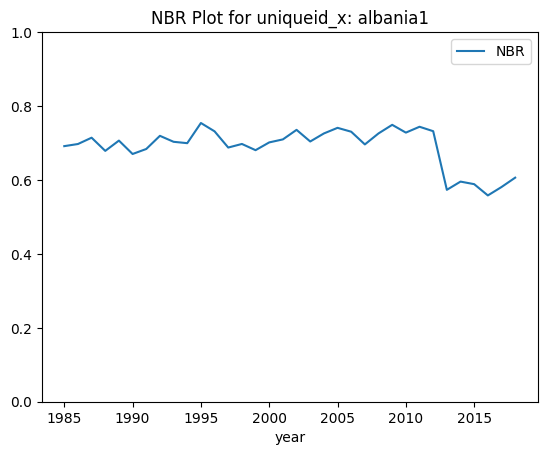

In [43]:
import random
fid = "albania1" #random.choice(df['uniqueid'].unique())
data = df.query('uniqueid == @fid')
data.plot(x='year',y='NBR',kind='line',title=f'NBR Plot for uniqueid_x: {fid}', ylim=(0,1))
data_numpy = data.to_numpy()

In [44]:
#random.seed(0)
#sample_ids = random.sample(sorted(df['uniqueid'].unique()), 100)

In [45]:
from tqdm import tqdm
import numpy

samples_data = []
samples_label = []

window_size = 16
missing = 0

for _, group in tqdm(df.groupby('uniqueid')):
    group = group.sort_values('year')
    if len(group) < 30:
        missing += 1
        continue
    data = group[['NIR', 'SW1', 'SW2','NBR','NDVI','TCB','TCG','TCW','DIn']].diff().fillna(0)
    label = group['class'].to_numpy()


    # Apply a rolling window of size to the data with slicing
    data = numpy.array([data[i:i+window_size].to_numpy() for i in range(len(data)-window_size+1)])
    label = numpy.array([label[i:i+window_size] for i in range(len(label)-window_size+1)])

    #data = data.reshape((1,data.shape[0],data.shape[1]))
    #label = label.reshape((1,len(label)))

    samples_data.append(data)
    samples_label.append(label)

X = samples_data
y = samples_label
print("missing")
print(missing)


100%|██████████| 11478/11478 [00:10<00:00, 1054.38it/s]

missing
7


In [46]:
from sklearn.model_selection import train_test_split

# X_train[i] is of the form (15, 20, 9), where 15 might vary ...
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.33, random_state=0)

#X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0) # 0.25 x 0.8 = 0.

In [47]:
# rasterio specify window size rasterio.window.window
# use normlalizer fitted on the training data --> save normalization

In [48]:
numpy.random.seed(0)

# unzip first dimension, so that we have arrays of shape (-1,20,9)
X_train_new = numpy.concatenate(X_train, axis=0)
X_val_new = numpy.concatenate(X_val, axis=0)
y_train_new = numpy.concatenate(y_train, axis=0)
y_val_new = numpy.concatenate(y_val, axis=0)


def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = numpy.random.permutation(len(a))
    return a[p], b[p]

X_train_new, y_train_new = unison_shuffled_copies(X_train_new, y_train_new)
X_val_new, y_val_new = unison_shuffled_copies(X_val_new, y_val_new)
#print(X_train_new.shape)
#print(X_test_new.shape)
  


In [49]:
# dimensions of X_train_new
# (number of samples, window_size, number of features)
print(X_train_new.shape)

(141899, 16, 9)


In [ ]:
# do fixed normalization
from sklearn.preprocessing import MinMaxScaler
min_train = X_train_new.min()
max_train = X_train_new.max()

X_train_scaled = (X_train_new - min_train) / (max_train - min_train)
X_val_scaled = (X_val_new - min_train) / (max_train - min_train)
y_train_scaled = y_train_new
y_val_scaled = y_val_new

#min-max scaling per band
# other normalization: mean, standard, quantile, ...

In [51]:
print(X_train_scaled.min())
print(X_train_scaled.max())
print(X_val_scaled.min())
print(X_val_scaled.max())

0.0
1.0
0.036869341822257234
0.9484128833239353


In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

class AlbasUNet(nn.Module):

    def __init__(self):

        super(AlbasUNet, self).__init__()

        n_channels_level_1 = 16
        n_channels_level_2 = 32
        n_channels_level_3 = 64
        n_channels_bottleneck = 128

        # input shape is (b,20,9), where b is the batch size
        # level 1
        self.conv1 = nn.Conv1d(in_channels=9,
                               out_channels=n_channels_level_1,
                               kernel_size=3,
                               padding=1)
        self.pool1 = nn.AvgPool1d(kernel_size=2)

        # level 2
        self.conv2 = nn.Conv1d(in_channels=n_channels_level_1,
                               out_channels=n_channels_level_2,
                               kernel_size=3,
                               padding=1)
        self.pool2 = nn.AvgPool1d(kernel_size=2)

        # level 3
        self.conv3 = nn.Conv1d(in_channels=n_channels_level_2,
                               out_channels=n_channels_level_3,
                               kernel_size=3,
                               padding=1)
        self.pool3 = nn.AvgPool1d(kernel_size=2)

        self.conv4 = nn.Conv1d(in_channels=n_channels_level_3,
                               out_channels=n_channels_bottleneck,
                               kernel_size=1,
                               padding=0)

        self.up3 = nn.ConvTranspose1d(in_channels=n_channels_bottleneck, #128
                               out_channels=n_channels_level_3, #64
                               kernel_size=2,
                               stride=2,
                               padding=0)

        self.up2 = nn.ConvTranspose1d(in_channels=2*n_channels_level_3,
                               out_channels=n_channels_level_2,
                               kernel_size=2,
                               stride=2,
                               padding=0)

        self.up1 = nn.ConvTranspose1d(in_channels=2*n_channels_level_2,
                               out_channels=n_channels_level_1,
                               kernel_size=2,
                               stride=2,
                               padding=0)


        self.out_conv = nn.Conv1d(in_channels=2*n_channels_level_1,
                               out_channels=1,
                               kernel_size=1,
                               padding=0)

        #self.dropout = nn.Dropout(0.5)
        self.loss = nn.BCELoss()

    def forward(self, x):

        x1_features = F.relu(self.conv1(x))
        x1 = self.pool1(x1_features)

        x2_features = F.relu(self.conv2(x1))
        x2 = self.pool2(x2_features)

        x3_features = F.relu(self.conv3(x2))
        x3 = self.pool3(x3_features)

        x4 = F.relu(self.conv4(x3))

        x = self.up3(x4)
        x = torch.concat([x,x3_features], dim=1)
        x = self.up2(x)
        x = torch.concat([x,x2_features], dim=1)
        x = self.up1(x)
        x = torch.concat([x,x1_features], dim=1)

        x = self.out_conv(x)

        return torch.sigmoid(x)


In [53]:
def prepare_data(train_data, train_labels, val_data, val_labels):

    # Convert numpy arrays to PyTorch tensors
    train_data_tensor = torch.Tensor(train_data)
    train_data_tensor = train_data_tensor.permute(0, 2, 1)
    train_labels_tensor = torch.Tensor(train_labels)

    val_data_tensor = torch.Tensor(val_data)
    val_data_tensor = val_data_tensor.permute(0, 2, 1)
    val_labels_tensor = torch.Tensor(val_labels)

    # Create datasets
    train_dataset = TensorDataset(train_data_tensor, train_labels_tensor)
    val_dataset = TensorDataset(val_data_tensor, val_labels_tensor)

    # Create WeightedRandomSampler with 0.7 and 0.3 weights for each class
    #class_weights = torch.tensor([ train_labels.sum()/len(train_labels),1-train_labels.sum()/len(train_labels)])
    #samples_weights_train = class_weights[train_labels_tensor.sum(axis=1).clip(0,1).long()]
    #samples_weights_val = class_weights[val_labels_tensor.sum(axis=1).clip(0,1).long()]
    #train_sampler = torch.utils.data.sampler.WeightedRandomSampler(samples_weights_train, len(samples_weights_train))
    #val_sampler = torch.utils.data.sampler.WeightedRandomSampler(samples_weights_val, len(samples_weights_val))


    # Create dataloaders
    train_loader = DataLoader(dataset=train_dataset,
                              batch_size=64,
                              shuffle=False,
                              num_workers=1,
                              persistent_workers=True)
                              #sampler=train_sampler)

    val_loader = DataLoader(dataset=val_dataset,
                            batch_size=64,
                            shuffle=False,
                            num_workers=1,
                            persistent_workers=True)
                            #sampler=val_sampler)

    return train_loader, val_loader

In [54]:
def train_epoch(model, train_loader, optimizer, device):
    model.train()
    train_losses = []
    true_labels, predictions = [], []

    for batch in tqdm(train_loader):
        x, y = batch
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        y_hat = model(x).squeeze()
        loss = model.loss(y_hat, y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        true_labels.extend(y.cpu().numpy())
        predictions.extend(torch.round(y_hat).detach().cpu().numpy())

    acc = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='micro')
    return np.mean(train_losses), acc, f1

def validate_epoch(model, test_val_loader, device):
    model.eval()
    val_losses = []
    true_labels, predictions = [], []

    with torch.no_grad():
        for batch in tqdm(test_val_loader):
            x, y = batch
            x, y = x.to(device), y.to(device)

            y_hat = model(x).squeeze()
            loss = model.loss(y_hat, y)

            val_losses.append(loss.item())
            true_labels.extend(y.cpu().numpy())
            predictions.extend(torch.round(y_hat).cpu().numpy())

    acc = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='micro')
    return np.mean(val_losses), acc, f1

In [55]:
import torch
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

# Check CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    torch.cuda.empty_cache()

CUDA Available: True
Current Device: 0
Device Name: NVIDIA GeForce RTX 3090


In [56]:
import torch
from torch.optim import Adam

# Check CUDA availability
if not torch.cuda.is_available():
    print("CUDA is unavailable. Using CPU.")
    device = torch.device("cpu")
else:
    print("CUDA is available!")
    device = torch.device("cuda:0")
    torch.cuda.empty_cache()

# Test a small tensor on the GPU
try:
    x = torch.rand(3, 3).to(device)
    print("GPU Test Passed")
except RuntimeError as e:
    print(f"GPU Test Failed: {e}")

# Print GPU memory info
if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"Total GPU Memory: {gpu_props.total_memory / (1024**3):.2f} GB")
    print(f"Allocated Memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
    print(f"Cached Memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

CUDA is available!
GPU Test Passed
Total GPU Memory: 23.59 GB
Allocated Memory: 0.00 GB
Cached Memory: 0.00 GB


In [57]:
try:
    model = AlbasUNet().to(device)
    optimizer = Adam(model.parameters())
    print("Model successfully moved to device")
except RuntimeError as e:
    print(f"Error loading model to GPU: {e}")

# Prepare data loaders
train_loader, val_loader = prepare_data(X_train_scaled,
                                        y_train_scaled,
                                        X_val_scaled,
                                        y_val_scaled)

# TensorBoard writer
#writer = SummaryWriter('runs/disturbance_detection')

# Training loop
for epoch in range(1, 50):

    # train for one epoch
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc, val_f1 = validate_epoch(model, val_loader, device)

    # Log metrics
    print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}')
    print(f'Epoch {epoch}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}')
    #print(f'Epoch {epoch}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}')

    writer.add_scalars('loss', {'train_loss': train_loss, 'val_loss': val_loss}, epoch)
    writer.add_scalars('accuracy', {'train_accuracy': train_acc, 'val_accuracy': val_acc}, epoch)
    writer.add_scalars('f1', {'train_f1': train_f1, 'val_f1': val_f1}, epoch)

    #writer.flush()
    

# Close writer
writer.close()

Model successfully moved to device


100%|██████████| 1093/1093 [00:02<00:00, 477.78it/s]


Epoch 1, Train Loss: 0.0412, Train Acc: 0.9245, Train F1: 0.0009
Epoch 1, Val Loss: 0.0357, Val Acc: 0.9213, Val F1: 0.0000


100%|██████████| 1093/1093 [00:02<00:00, 525.42it/s]


Epoch 2, Train Loss: 0.0311, Train Acc: 0.9254, Train F1: 0.0171
Epoch 2, Val Loss: 0.0234, Val Acc: 0.9222, Val F1: 0.0249


...

Epoch 4, Train Loss: 0.0223, Train Acc: 0.9362, Train F1: 0.3102
Epoch 4, Val Loss: 0.0201, Val Acc: 0.9344, Val F1: 0.3465


100%|██████████| 1093/1093 [00:02<00:00, 518.75it/s]


Epoch 5, Train Loss: 0.0218, Train Acc: 0.9373, Train F1: 0.3453
Epoch 5, Val Loss: 0.0198, Val Acc: 0.9354, Val F1: 0.3682


 86%|████████▌ | 1910/2218 [00:09<00:01, 193.18it/s]


KeyboardInterrupt: 

In [ ]:
# plot confusion matrix
#sklearn.metrics.multilabel_confusion_matrix
import sklearn.metrics as skm
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('Confusion Matrix')
    plt.show()

# Get predictions
true_labels, predictions = [], []
model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader):
        x, y = batch
        x, y = x.to(device), y.to(device)

        y_hat = model(x).squeeze()
        true_labels.extend(y.cpu().numpy())
        predictions.extend(torch.round(y_hat).cpu().numpy())

# Plot confusion matrix
class_names = ['No Disturbance', 'Disturbance']
# plot multilabel confusion matrix  

cm = skm.multilabel_confusion_matrix(true_labels, predictions)
print(cm)
print( skm.classification_report(true_labels, predictions))
#plot_confusion_matrix(true_labels.argmax(axis=1), predictions.argmax(axis=1), class_names)

# Save model
torch.save(model.state_dict(), 'model.pth')


  5%|▌         | 55/1093 [00:00<00:01, 543.13it/s]

100%|██████████| 1093/1093 [00:02<00:00, 543.84it/s]


[[[69419    99]
  [  285   116]]

 [[69434    78]
  [  271   136]]

 [[69419    96]
  [  263   141]]

 [[69438    84]
  [  259   138]]

 [[69426   104]
  [  233   156]]

 [[69414   109]
  [  238   158]]

 [[69431    99]
  [  240   149]]

 [[69431    95]
  [  241   152]]

 [[69437    89]
  [  235   158]]

 [[69414    99]
  [  240   166]]

 [[69410    92]
  [  248   169]]

 [[69410    88]
  [  269   152]]

 [[69409    88]
  [  245   177]]

 [[69413    86]
  [  240   180]]

 [[69416    83]
  [  239   181]]

 [[69409    86]
  [  268   156]]]
              precision    recall  f1-score   support

           0       0.54      0.29      0.38       401
           1       0.64      0.33      0.44       407
           2       0.59      0.35      0.44       404
           3       0.62      0.35      0.45       397
           4       0.60      0.40      0.48       389
           5       0.59      0.40      0.48       396
           6       0.60      0.38      0.47       389
           7       0.62

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#pred = model(torch.from_numpy(X_train_scaled[0:10].transpose(0,2,1)).float())

In [ ]:
#pred.shape